In [18]:
'''
기본적인 개념 : State, Node, Edge, Conditional Edge


State : 상태 - 현재 Agent의 상태(데이터)
Node  : Agent가 수행하는 작업(함수)
Edge  : Node 간의 관계를 설명(워크플로)
Conditional Edge : Node 간의 관계를 설명(갈림길)
'''

'\n기본적인 개념 : State, Node, Edge, Conditional Edge\n\n\nState : 상태 - 현재 Agent의 상태(데이터)\nNode  : Agent가 수행하는 작업(함수)\nEdge  : Node 간의 관계를 설명(워크플로)\nConditional Edge : Node 간의 관계를 설명(갈림길)\n'

In [ ]:
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic


load_dotenv()

llm = ChatAnthropic(model= 'claude-sonnet-4-20250514')

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [27]:
query = '대손충당금에 대해서 설명해주세요'

## State

In [20]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]]     
# state update 시 Annotated의 두번째 인자를 보고 처리함

In [21]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [ ]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class Agent

## Node

In [22]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

graph_builder.add_node('generate', generate)

## START, END

In [23]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

## Compile

In [24]:
graph = graph_builder.compile()

## 사용

In [29]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}

In [31]:
initial_state

{'messages': [HumanMessage(content='대손충당금에 대해서 설명해주세요', additional_kwargs={}, response_metadata={})]}

In [30]:
graph.invoke(initial_state)

{'messages': [AIMessage(content='대손충당금(貸損充當金, Allowance for Bad Debts)에 대해 자세히 설명드리겠습니다.\n\n## 1. 대손충당금의 개념\n\n**대손충당금**은 기업이 보유한 매출채권(외상매출금, 받을어음 등) 중 회수가 불가능할 것으로 예상되는 금액에 대해 미리 설정해두는 충당금입니다.\n\n## 2. 설정 목적\n\n- **보수주의 원칙** 적용: 미래 손실을 미리 반영\n- **재무제표의 신뢰성** 제고\n- **매출채권의 실질가치** 표시\n- **기간 대응원칙** 실현\n\n## 3. 설정 방법\n\n### 가. 개별평가법\n- 개별 채권별로 회수 가능성 검토\n- 대규모 채권에 적용\n\n### 나. 총괄평가법\n```\n대손충당금 = 매출채권 잔액 × 대손율\n```\n- 과거 대손 경험률 활용\n- 채권 연령별 차등 적용\n\n## 4. 회계처리\n\n### 가. 대손충당금 설정\n```\n(차) 대손상각비         xxx\n    (대) 대손충당금          xxx\n```\n\n### 나. 실제 대손 발생\n```\n(차) 대손충당금         xxx\n    (대) 매출채권            xxx\n```\n\n### 다. 상각채권 회수\n```\n(차) 매출채권           xxx\n    (대) 대손충당금회입       xxx\n\n(차) 현금               xxx\n    (대) 매출채권            xxx\n```\n\n## 5. 재무제표 표시\n\n**재정상태표**에서:\n```\n매출채권                1,000,000\n차감: 대손충당금          (50,000)\n매출채권 순액             950,000\n```\n\n## 6. 세무상 취급\n\n- **법인세법상** 손금인정 기준이 별도로 존재\n- 회계상 설정액과 세무상 인정액 차이 발생 가능\n- 일시차이로 인한 이연법인세 인식 필요\n\n## 7.

## 시각화

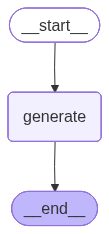

In [26]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))